# SafeType — Exploratory Data Analysis (EDA)

This notebook explores the datasets used in the SafeType project, providing visual insights that motivate the modeling and feature engineering decisions made in our pipeline.

**Sections:**
1. Dataset Overview & Class Distribution
2. Text Length Analysis by Category
3. High-Frequency Words & Word Clouds
4. TF-IDF Feature Analysis
5. Handcrafted Features Analysis
6. Data Source Comparison
7. Error Analysis Preview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
from scipy import sparse
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
LABEL_NAMES = [
    "clean", "racism", "sexism", "profanity", "cyberbullying",
    "toxicity", "hate_speech", "implicit_hate", "threat", "sarcasm",
]
COLORS = {
    "clean": "#10b981", "racism": "#ef4444", "sexism": "#f97316",
    "profanity": "#eab308", "cyberbullying": "#ec4899", "toxicity": "#a855f7",
    "hate_speech": "#dc2626", "implicit_hate": "#f59e0b", "threat": "#b91c1c",
    "sarcasm": "#6366f1",
}
PALETTE = [COLORS[l] for l in LABEL_NAMES]

DATA_DIR = Path("../data")
MODELS_DIR = Path("../models")

unified = pd.read_csv(DATA_DIR / "processed" / "unified_toxicity_data.csv")
balanced = pd.read_csv(DATA_DIR / "processed" / "balanced_toxicity_data.csv")
train_df = pd.read_csv(DATA_DIR / "processed" / "train.csv")
test_df = pd.read_csv(DATA_DIR / "processed" / "test.csv")

print(f"Unified dataset: {len(unified):,} samples")
print(f"Balanced dataset: {len(balanced):,} samples")
print(f"Train set: {len(train_df):,} | Test set: {len(test_df):,}")

Unified dataset: 374,675 samples
Balanced dataset: 50,000 samples
Train set: 40,000 | Test set: 10,000


## 1. Dataset Overview & Class Distribution

We combined eight data sources: Davidson, Jigsaw v1, Jigsaw v2, Berkeley D-Lab, EDOS, HateXplain, ImplicitHate, and TweetEval irony (sarcasm). The unified dataset has **10 classes**: clean, racism, sexism, profanity, cyberbullying, toxicity, hate_speech, implicit_hate, threat, sarcasm. The raw combined data is heavily imbalanced — "clean" dominates. This motivates the balanced sampling strategy in `make_dataset.py`.

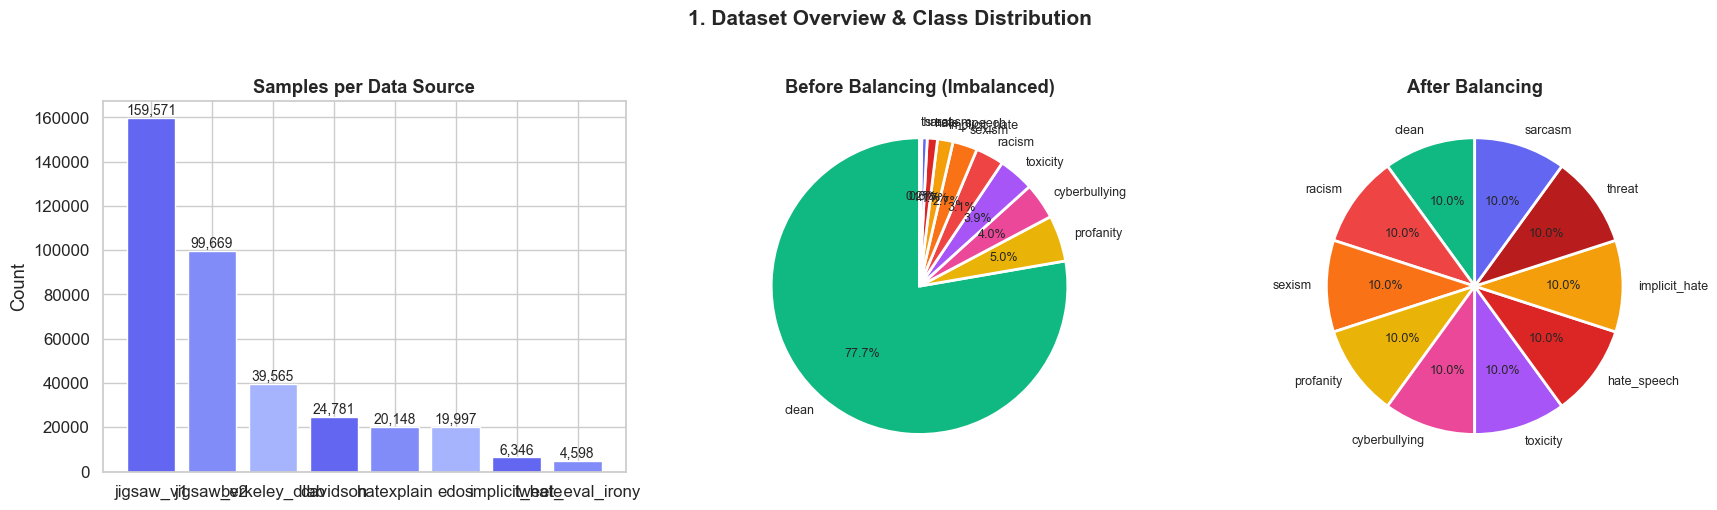

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1a — Per-source sample counts
source_counts = unified["source"].value_counts()
bars = axes[0].bar(source_counts.index, source_counts.values, color=["#6366f1", "#818cf8", "#a5b4fc"], edgecolor="white")
axes[0].set_title("Samples per Data Source", fontweight="bold")
axes[0].set_ylabel("Count")
for bar, v in zip(bars, source_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 1500, f"{v:,}", ha="center", fontsize=10)

# 1b — Unified (imbalanced) label distribution
label_counts = unified["label"].value_counts()
axes[1].pie(label_counts.values, labels=label_counts.index, autopct="%1.1f%%",
            colors=[COLORS.get(l, "#888") for l in label_counts.index], startangle=90,
            textprops={"fontsize": 9}, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Before Balancing (Imbalanced)", fontweight="bold")

# 1c — Balanced label distribution
bal_counts = balanced["label"].value_counts()
axes[2].pie(bal_counts.values, labels=bal_counts.index, autopct="%1.1f%%",
            colors=[COLORS.get(l, "#888") for l in bal_counts.index], startangle=90,
            textprops={"fontsize": 9}, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[2].set_title("After Balancing", fontweight="bold")

plt.suptitle("1. Dataset Overview & Class Distribution", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

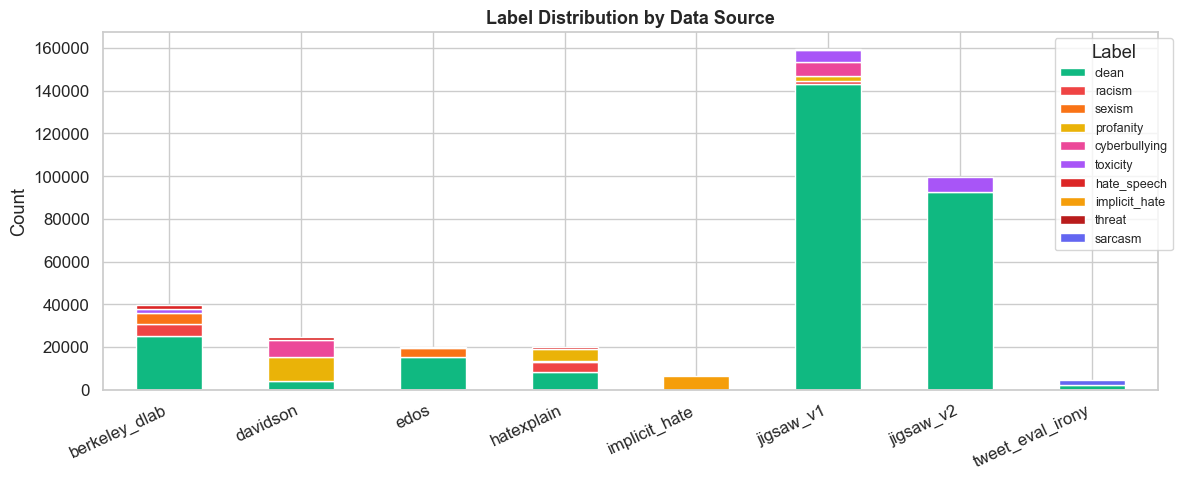


Cross-tabulation (columns = labels):
label              clean  racism  sexism  profanity  cyberbullying  toxicity  \
source                                                                         
berkeley_dlab      25255    5262    5403          0              0      1921   
davidson            4163       0       0      10879           8310         0   
edos               15143       0    4411          0              0         0   
hatexplain          8153    4976     249       5761              0         0   
implicit_hate          0       0       0          0              0         0   
jigsaw_v1         143346    1307       0       2233           6500      5707   
jigsaw_v2          92761       0       0          0              0      6908   
tweet_eval_irony    2388       0       0          0              0         0   

label             hate_speech  implicit_hate  threat  sarcasm  
source                                                         
berkeley_dlab            1724    

In [3]:
# 1d — Label distribution breakdown per source (stacked bar)
cross = pd.crosstab(unified["source"], unified["label"])
cols = [c for c in LABEL_NAMES if c in cross.columns]
cross = cross[cols]

fig, ax = plt.subplots(figsize=(12, 5))
pal = [COLORS[c] for c in cols]
cross.plot(kind="bar", stacked=True, color=pal, edgecolor="white", ax=ax)
ax.set_title("Label Distribution by Data Source", fontweight="bold", fontsize=13)
ax.set_ylabel("Count")
ax.set_xlabel("")
ax.legend(title="Label", frameon=True, bbox_to_anchor=(1.02, 1), fontsize=9)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

print("\nCross-tabulation (columns = labels):")
print(cross)
vc = unified["label"].value_counts()
min_label, min_count = vc.idxmin(), vc.min()
print(f"\nSmallest class: {min_label} = {min_count:,} | Clean = {vc.get('clean', 0):,}")

## 2. Text Length Analysis

Text length (characters and words) can differ significantly across categories. This analysis validates our handcrafted features (`char_count`, `word_count`, `avg_word_len`) in `build_features.py` and confirms that DistilBERT's `max_len=128` tokens is sufficient.

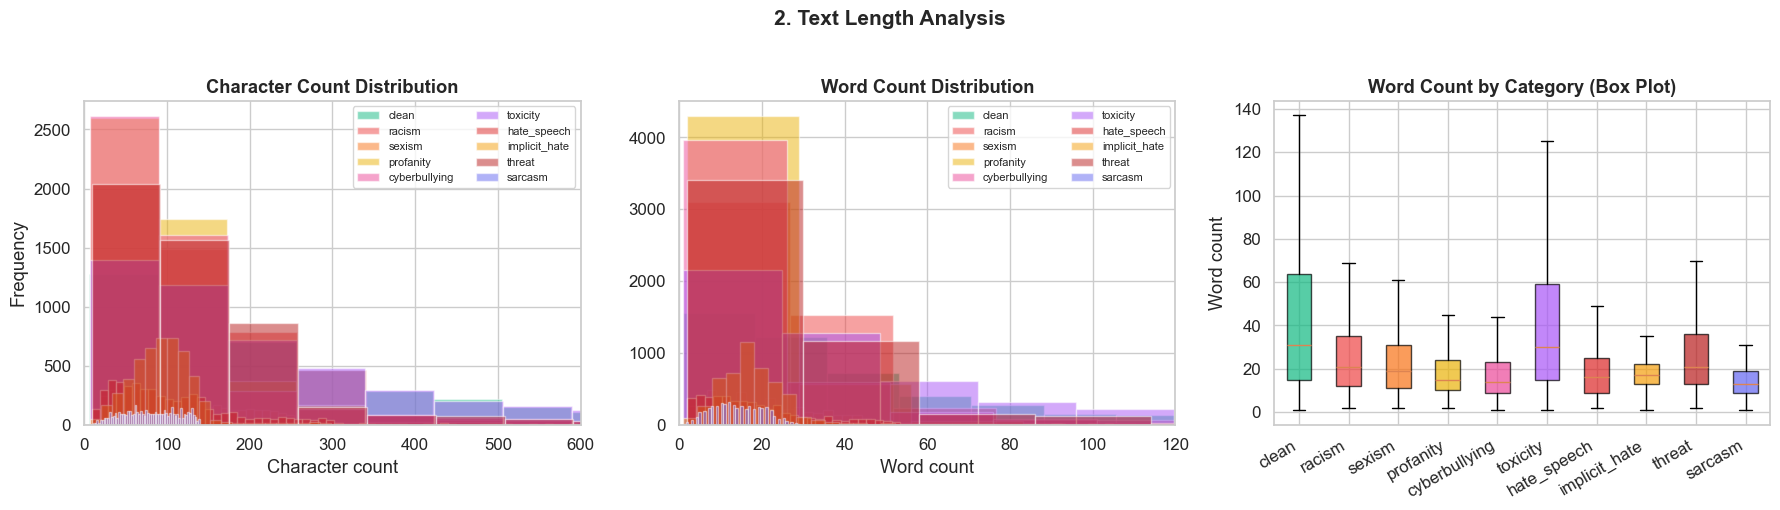

In [4]:
balanced["char_count"] = balanced["text"].str.len()
balanced["word_count"] = balanced["text"].str.split().str.len()
balanced["avg_word_len"] = balanced["char_count"] / balanced["word_count"].clip(lower=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2a — Character count distribution
for label in LABEL_NAMES:
    if label not in balanced["label"].values:
        continue
    subset = balanced[balanced["label"] == label]["char_count"]
    axes[0].hist(subset, bins=60, alpha=0.5, label=label, color=COLORS[label], edgecolor="white")
axes[0].set_title("Character Count Distribution", fontweight="bold")
axes[0].set_xlabel("Character count")
axes[0].set_ylabel("Frequency")
axes[0].legend(fontsize=8, ncol=2)
axes[0].set_xlim(0, 600)

# 2b — Word count distribution
for label in LABEL_NAMES:
    if label not in balanced["label"].values:
        continue
    subset = balanced[balanced["label"] == label]["word_count"]
    axes[1].hist(subset, bins=50, alpha=0.5, label=label, color=COLORS[label], edgecolor="white")
axes[1].set_title("Word Count Distribution", fontweight="bold")
axes[1].set_xlabel("Word count")
axes[1].legend(fontsize=8, ncol=2)
axes[1].set_xlim(0, 120)

# 2c — Box plot of word count per label
bp_data = [balanced[balanced["label"] == l]["word_count"].dropna() for l in LABEL_NAMES if l in balanced["label"].values]
bp_labels = [l for l in LABEL_NAMES if l in balanced["label"].values]
bp = axes[2].boxplot(bp_data, labels=bp_labels, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], [COLORS[l] for l in bp_labels]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_xticklabels(bp_labels, rotation=30, ha="right")
axes[2].set_title("Word Count by Category (Box Plot)", fontweight="bold")
axes[2].set_ylabel("Word count")

plt.suptitle("2. Text Length Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

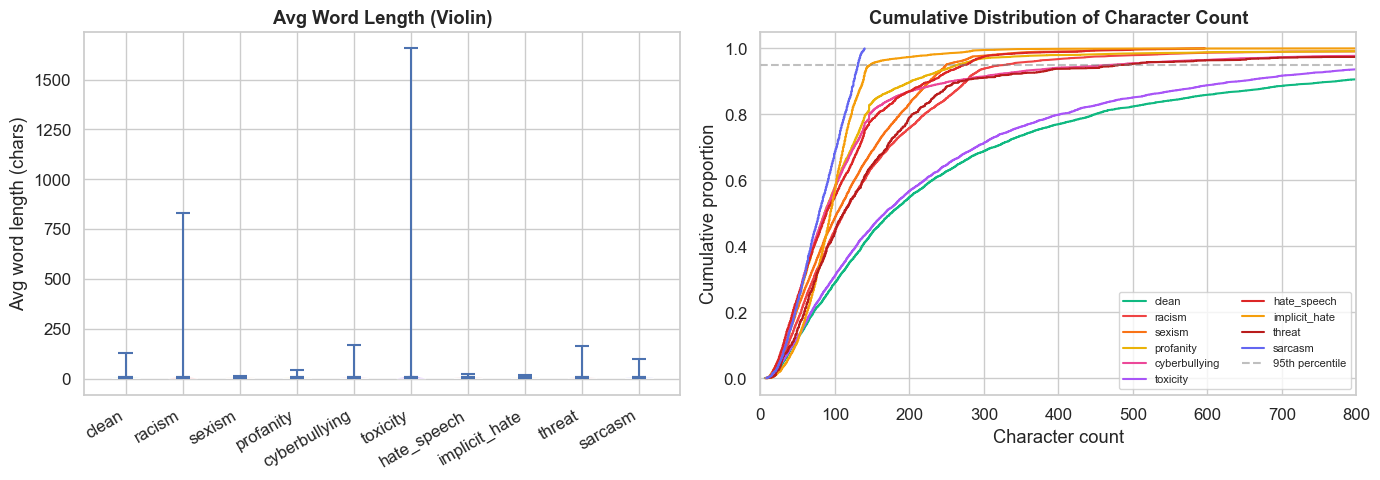

Text length stats by label:
label                clean  cyberbullying  hate_speech  implicit_hate  \
char_count   count  5000.0         5000.0       5000.0         5000.0   
             mean    329.0          170.5        110.3           96.3   
             std     498.4          456.3         82.0           45.8   
             min       6.0            7.0          9.0            7.0   
             25%      88.0           51.0         51.0           69.0   
             50%     176.0           86.0         89.0           94.0   
             75%     368.0          138.0        140.0          116.0   
             max    4999.0         5000.0        596.0          801.0   
word_count   count  5000.0         5000.0       5000.0         5000.0   
             mean     56.5           29.0         19.5           17.9   
             std      83.6           77.0         14.7            9.0   
             min       1.0            1.0          2.0            1.0   
             25%      1

In [5]:
# 2d — Violin plot for avg word length & cumulative distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels_present = [l for l in LABEL_NAMES if l in balanced["label"].values]
n_c = len(labels_present)

# Violin plot
parts = axes[0].violinplot(
    [balanced[balanced["label"] == l]["avg_word_len"].dropna() for l in labels_present],
    positions=range(1, n_c + 1), showmeans=True, showmedians=True
)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(COLORS[labels_present[i]])
    pc.set_alpha(0.7)
axes[0].set_xticks(range(1, n_c + 1))
axes[0].set_xticklabels(labels_present, rotation=30, ha="right")
axes[0].set_title("Avg Word Length (Violin)", fontweight="bold")
axes[0].set_ylabel("Avg word length (chars)")

# CDF of character count
for label in labels_present:
    subset = balanced[balanced["label"] == label]["char_count"].sort_values()
    cdf = np.arange(1, len(subset)+1) / len(subset)
    axes[1].plot(subset, cdf, label=label, color=COLORS[label], linewidth=1.5)
axes[1].axhline(y=0.95, color="gray", linestyle="--", alpha=0.5, label="95th percentile")
axes[1].set_title("Cumulative Distribution of Character Count", fontweight="bold")
axes[1].set_xlabel("Character count")
axes[1].set_ylabel("Cumulative proportion")
axes[1].legend(fontsize=8, ncol=2)
axes[1].set_xlim(0, 800)

plt.tight_layout()
plt.show()

# Summary stats
print("Text length stats by label:")
print(balanced.groupby("label")[["char_count", "word_count", "avg_word_len"]].describe().round(1).T)

## 3. High-Frequency Words & Word Clouds

Examining the most common words in each category helps us understand: (a) why the Naive Baseline keyword list works for some cases, and (b) what patterns TF-IDF and DistilBERT can leverage.

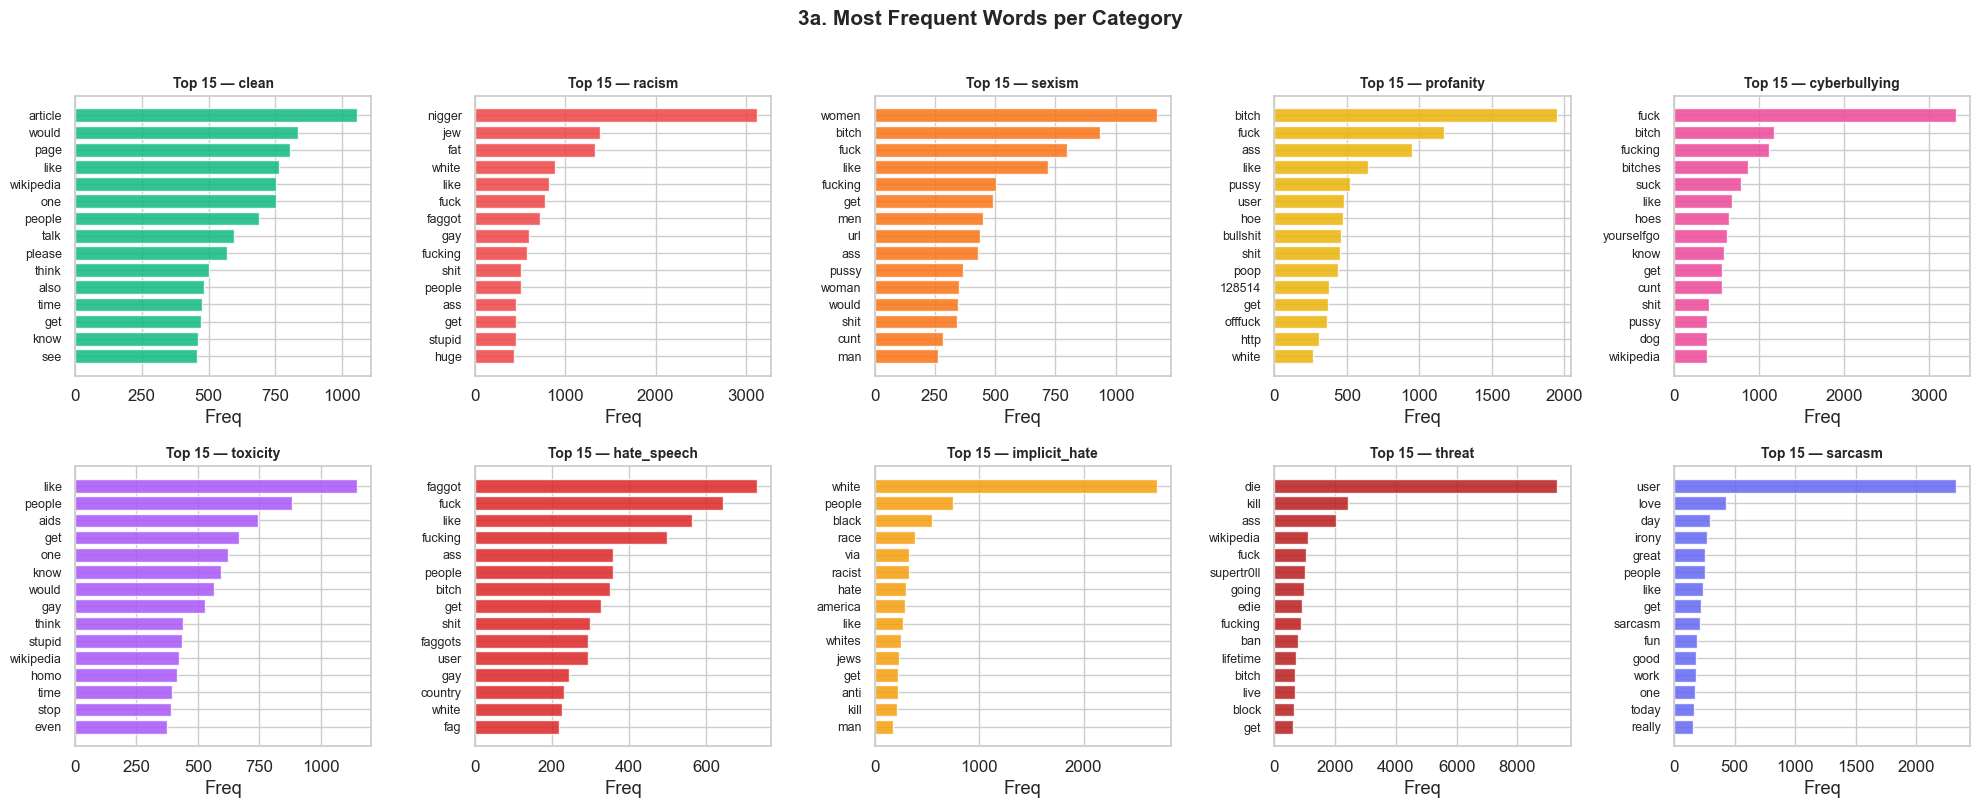

In [6]:
import re
from nltk.corpus import stopwords
import nltk
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

def get_top_words(texts, n=20):
    words = []
    for t in texts:
        t = re.sub(r"[^\w\s]", " ", str(t).lower())
        words.extend([w for w in t.split() if w not in stop_words and len(w) > 2])
    return Counter(words).most_common(n)

labels_present = [l for l in LABEL_NAMES if l in balanced["label"].values]
n_c = len(labels_present)
n_cols = 5
n_rows = (n_c + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = np.atleast_2d(axes)
for i, label in enumerate(labels_present):
    r, c = i // n_cols, i % n_cols
    ax = axes[r, c]
    subset = balanced[balanced["label"] == label]["text"]
    top = get_top_words(subset, 15)
    if not top:
        ax.set_title(label, fontsize=10)
        ax.axis("off")
        continue
    words, counts = zip(*top)
    y_pos = range(len(words))
    ax.barh(y_pos, counts, color=COLORS[label], edgecolor="white", alpha=0.85)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f"Top 15 — {label}", fontweight="bold", fontsize=10)
    ax.set_xlabel("Freq")
for j in range(i + 1, n_rows * n_cols):
    r, c = j // n_cols, j % n_cols
    axes[r, c].axis("off")
plt.suptitle("3a. Most Frequent Words per Category", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

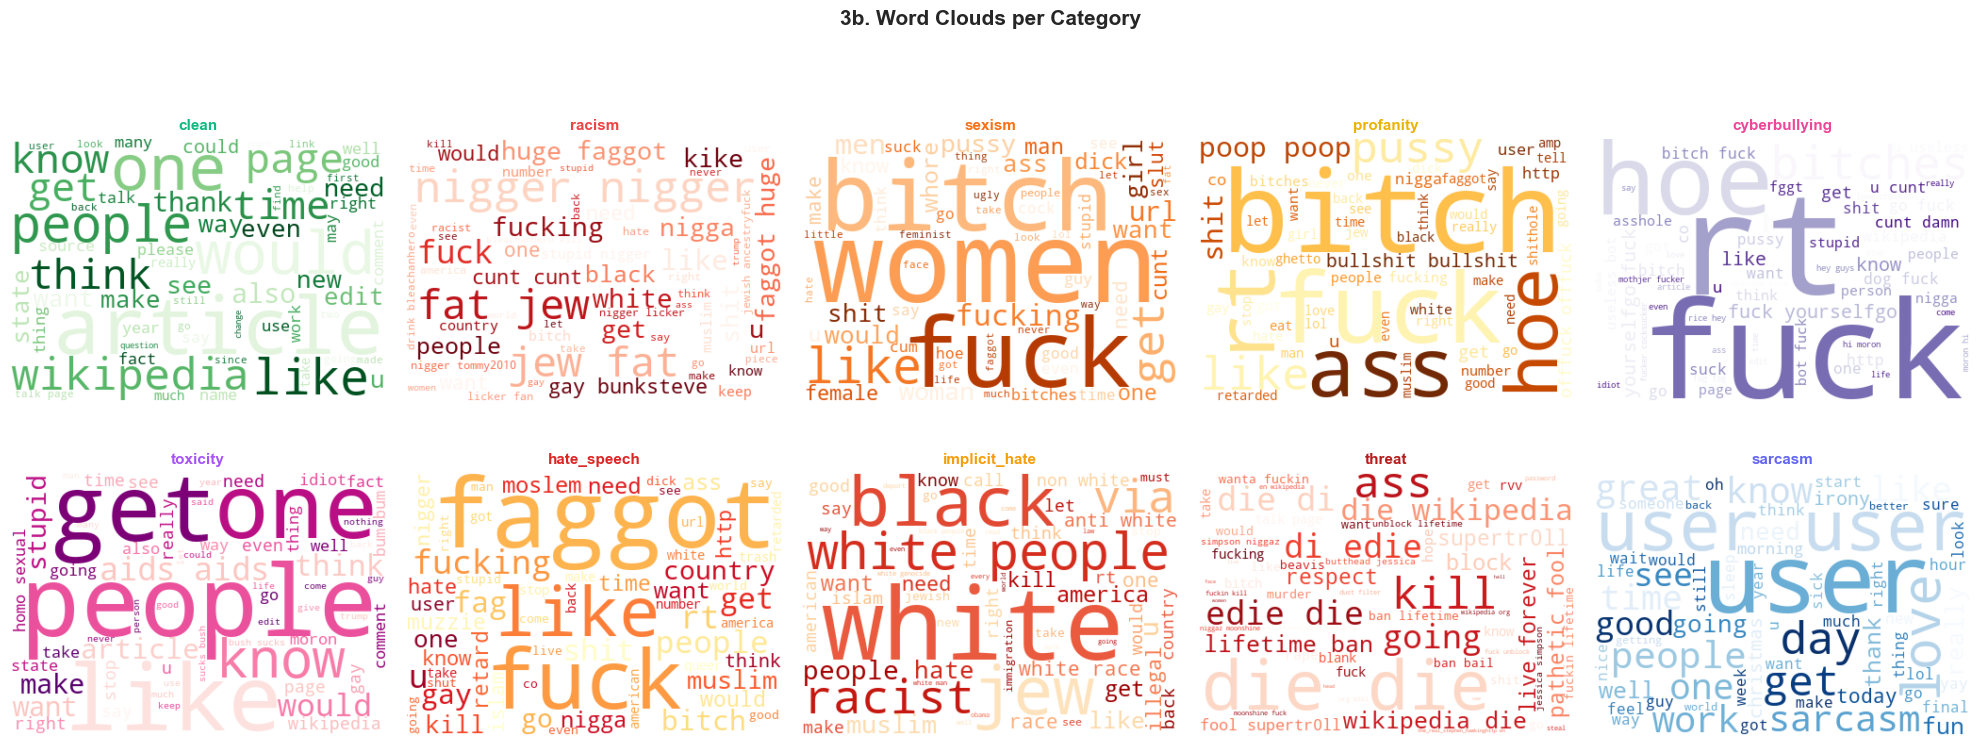

In [7]:
try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    HAS_WORDCLOUD = False
    print("wordcloud not installed. Run: pip install wordcloud")

if HAS_WORDCLOUD:
    labels_present = [l for l in LABEL_NAMES if l in balanced["label"].values]
    n_c = len(labels_present)
    n_cols = 5
    n_rows = (n_c + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
    axes = np.atleast_2d(axes)
    cmaps = ["Greens", "Reds", "Oranges", "YlOrBr", "Purples", "RdPu", "YlOrRd", "OrRd", "Reds", "Blues"]
    for i, label in enumerate(labels_present):
        r, c = i // n_cols, i % n_cols
        ax = axes[r, c]
        subset = balanced[balanced["label"] == label]["text"]
        text_blob = " ".join(re.sub(r"[^\w\s]", " ", str(t).lower()) for t in subset)
        wc = WordCloud(width=400, height=280, background_color="white", colormap=cmaps[i % len(cmaps)],
                       stopwords=stop_words, max_words=60, contour_width=1, contour_color=COLORS[label]).generate(text_blob)
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(label, fontweight="bold", fontsize=11, color=COLORS[label])
        ax.axis("off")
    for j in range(n_c, n_rows * n_cols):
        axes[j // n_cols, j % n_cols].axis("off")
    plt.suptitle("3b. Word Clouds per Category", fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

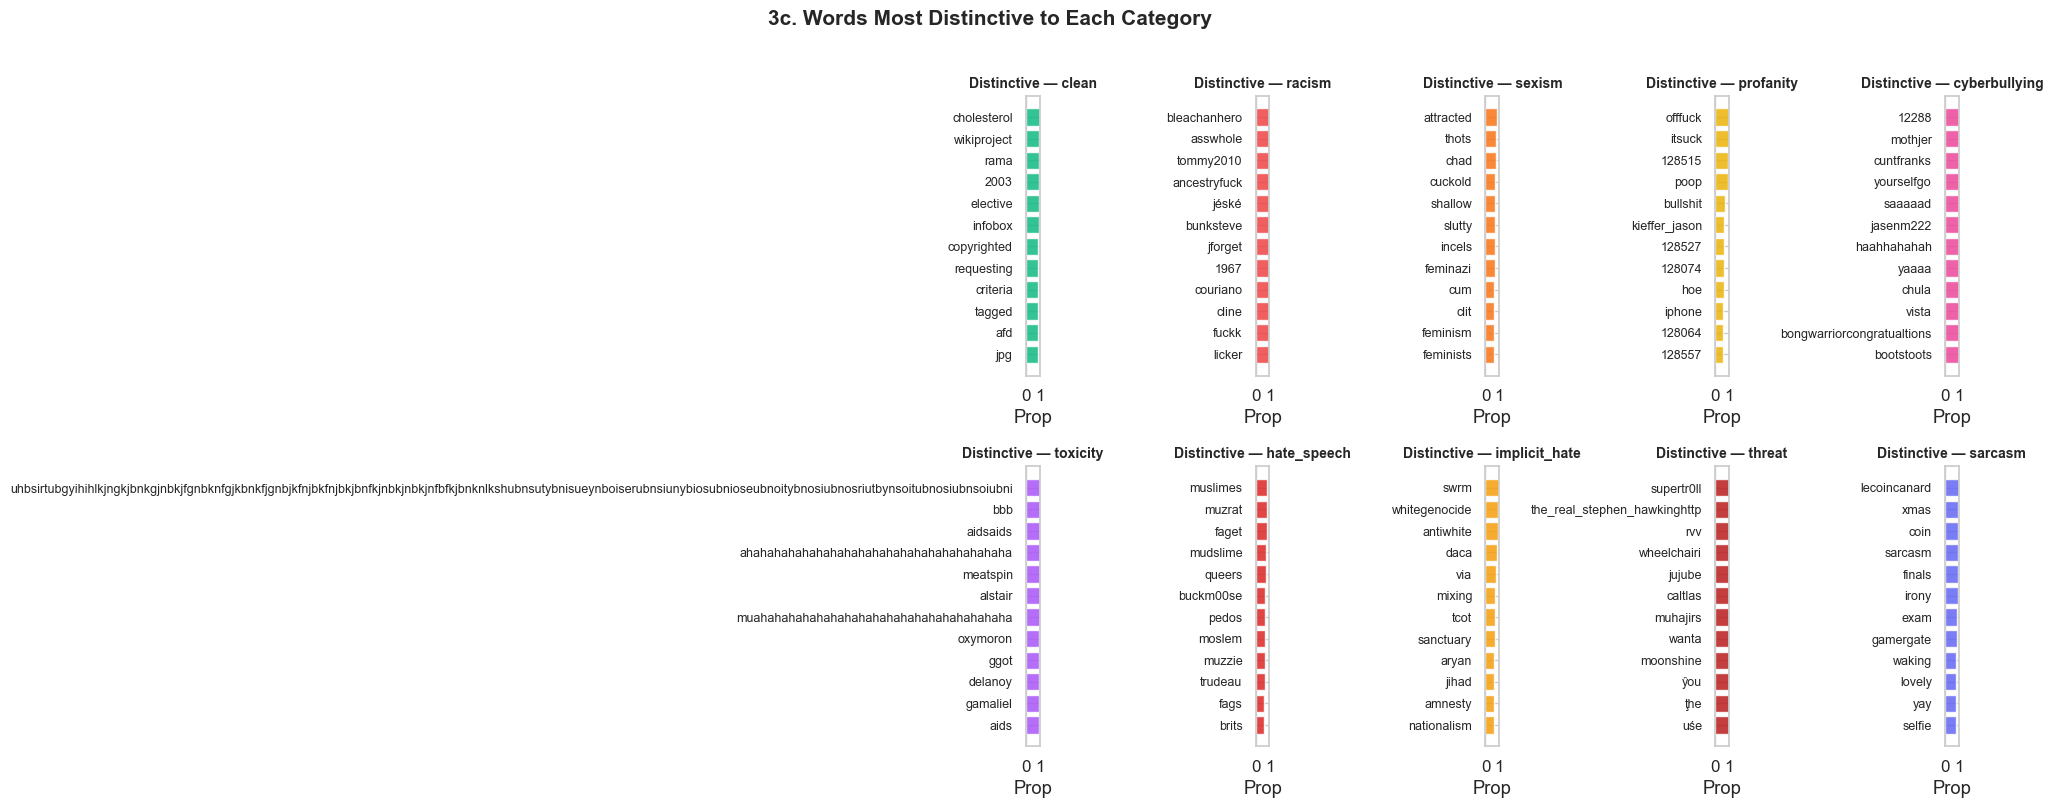

In [8]:
# 3c — Unique / distinctive words per category
labels_present = [l for l in LABEL_NAMES if l in balanced["label"].values]
all_words = {}
for label in labels_present:
    subset = balanced[balanced["label"] == label]["text"]
    words = []
    for t in subset:
        t = re.sub(r"[^\w\s]", " ", str(t).lower())
        words.extend([w for w in t.split() if w not in stop_words and len(w) > 2])
    all_words[label] = Counter(words)

total = sum(all_words.values(), Counter())
n_c = len(labels_present)
n_cols = 5
n_rows = (n_c + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = np.atleast_2d(axes)
for i, label in enumerate(labels_present):
    ratios = {}
    for word, count in all_words[label].items():
        if total[word] >= 20:
            ratios[word] = count / total[word]
    top_distinct = sorted(ratios.items(), key=lambda x: -x[1])[:12]
    if not top_distinct:
        axes[i // n_cols, i % n_cols].set_title(label, fontsize=10)
        axes[i // n_cols, i % n_cols].axis("off")
        continue
    words, scores = zip(*top_distinct)
    r, c = i // n_cols, i % n_cols
    ax = axes[r, c]
    y_pos = range(len(words))
    ax.barh(y_pos, scores, color=COLORS[label], edgecolor="white", alpha=0.85)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f"Distinctive — {label}", fontweight="bold", fontsize=10)
    ax.set_xlabel("Prop")
    ax.set_xlim(0, 1)
for j in range(n_c, n_rows * n_cols):
    axes[j // n_cols, j % n_cols].axis("off")
plt.suptitle("3c. Words Most Distinctive to Each Category", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 4. TF-IDF Feature Analysis

We examine the top TF-IDF weighted terms for each class, which directly validates the feature engineering choices in `build_features.py` (ngram_range=(1,2), max_features=20,000).

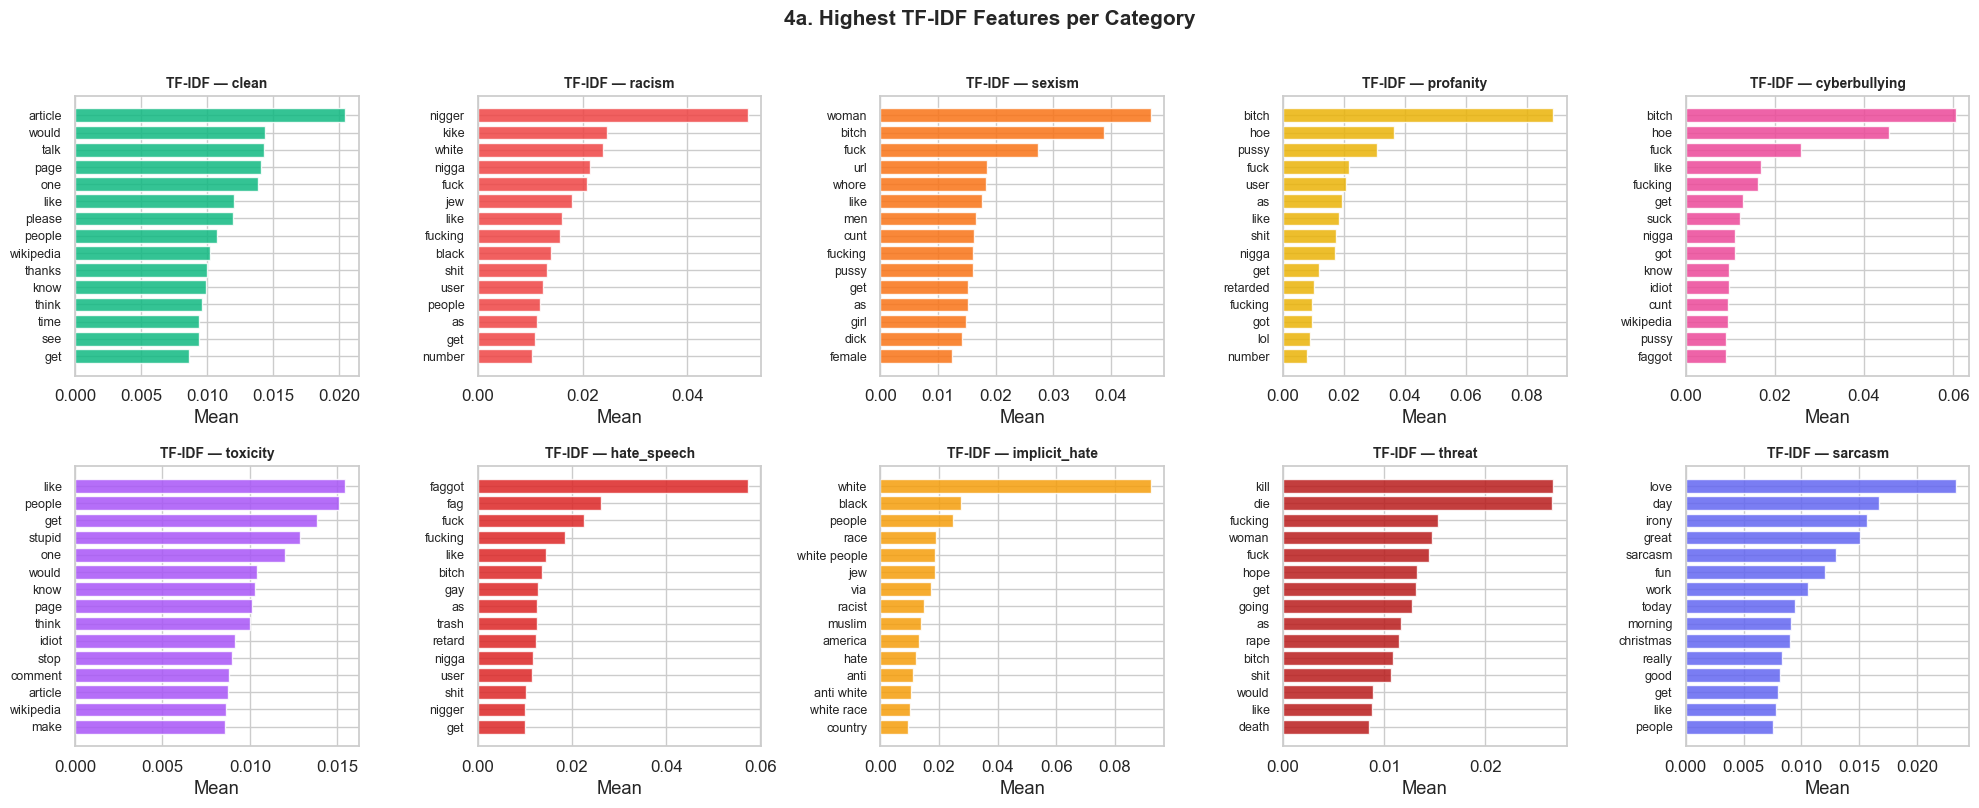


Total vocabulary size: 20,000
TF-IDF matrix shape: (40000, 20000)
Sparsity: 99.9309%


In [9]:
vectorizer = joblib.load(MODELS_DIR / "tfidf_vectorizer.pkl")
X_train_tfidf = sparse.load_npz(DATA_DIR / "processed" / "X_train_tfidf.npz")
feature_names = np.array(vectorizer.get_feature_names_out())

label_names_tf = [l for l in LABEL_NAMES if l in train_df["label"].values]
n_c = len(label_names_tf)
n_cols = 5
n_rows = (n_c + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = np.atleast_2d(axes)
for i, label in enumerate(label_names_tf):
    mask = train_df["label"] == label
    mean_tfidf = X_train_tfidf[mask.values].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-15:][::-1]
    top_words = feature_names[top_idx]
    top_scores = mean_tfidf[top_idx]
    r, c = i // n_cols, i % n_cols
    ax = axes[r, c]
    y_pos = range(len(top_words))
    ax.barh(y_pos, top_scores, color=COLORS[label], edgecolor="white", alpha=0.85)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_words, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f"TF-IDF — {label}", fontweight="bold", fontsize=10)
    ax.set_xlabel("Mean")
for j in range(n_c, n_rows * n_cols):
    axes[j // n_cols, j % n_cols].axis("off")
plt.suptitle("4a. Highest TF-IDF Features per Category", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\nTotal vocabulary size: {len(feature_names):,}")
print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")
print(f"Sparsity: {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])):.4%}")

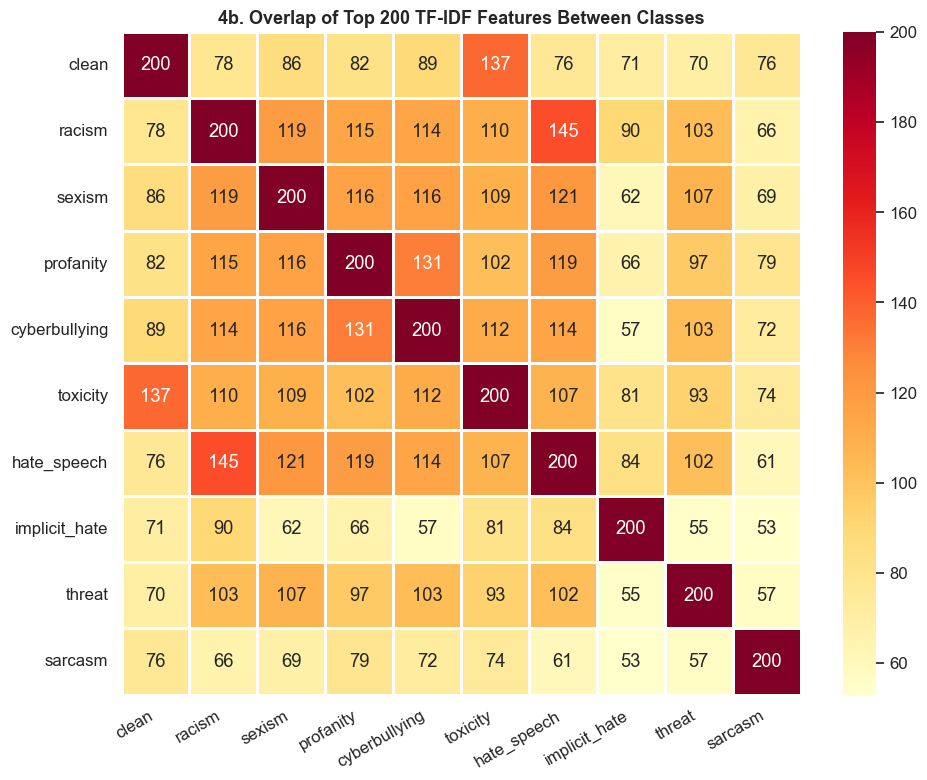

In [10]:
# 4b — TF-IDF feature overlap heatmap
top_n = 200
top_per_class = {}
for label in label_names_tf:
    mask = train_df["label"] == label
    mean_tfidf = X_train_tfidf[mask.values].mean(axis=0).A1
    top_per_class[label] = set(mean_tfidf.argsort()[-top_n:])

n_c = len(label_names_tf)
overlap_matrix = np.zeros((n_c, n_c))
for i, l1 in enumerate(label_names_tf):
    for j, l2 in enumerate(label_names_tf):
        overlap_matrix[i, j] = len(top_per_class[l1] & top_per_class[l2])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(overlap_matrix, annot=True, fmt=".0f", cmap="YlOrRd",
            xticklabels=label_names_tf, yticklabels=label_names_tf, ax=ax,
            linewidths=1, linecolor="white")
ax.set_xticklabels(label_names_tf, rotation=30, ha="right")
ax.set_yticklabels(label_names_tf, rotation=0)
ax.set_title(f"4b. Overlap of Top {top_n} TF-IDF Features Between Classes", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Handcrafted Features Analysis

Our `build_features.py` extracts 7 handcrafted features: `char_count`, `word_count`, `avg_word_len`, `uppercase_ratio`, `exclamation_count`, `question_count`, `caps_word_count`. We visualize their distributions to see which features discriminate between labels.

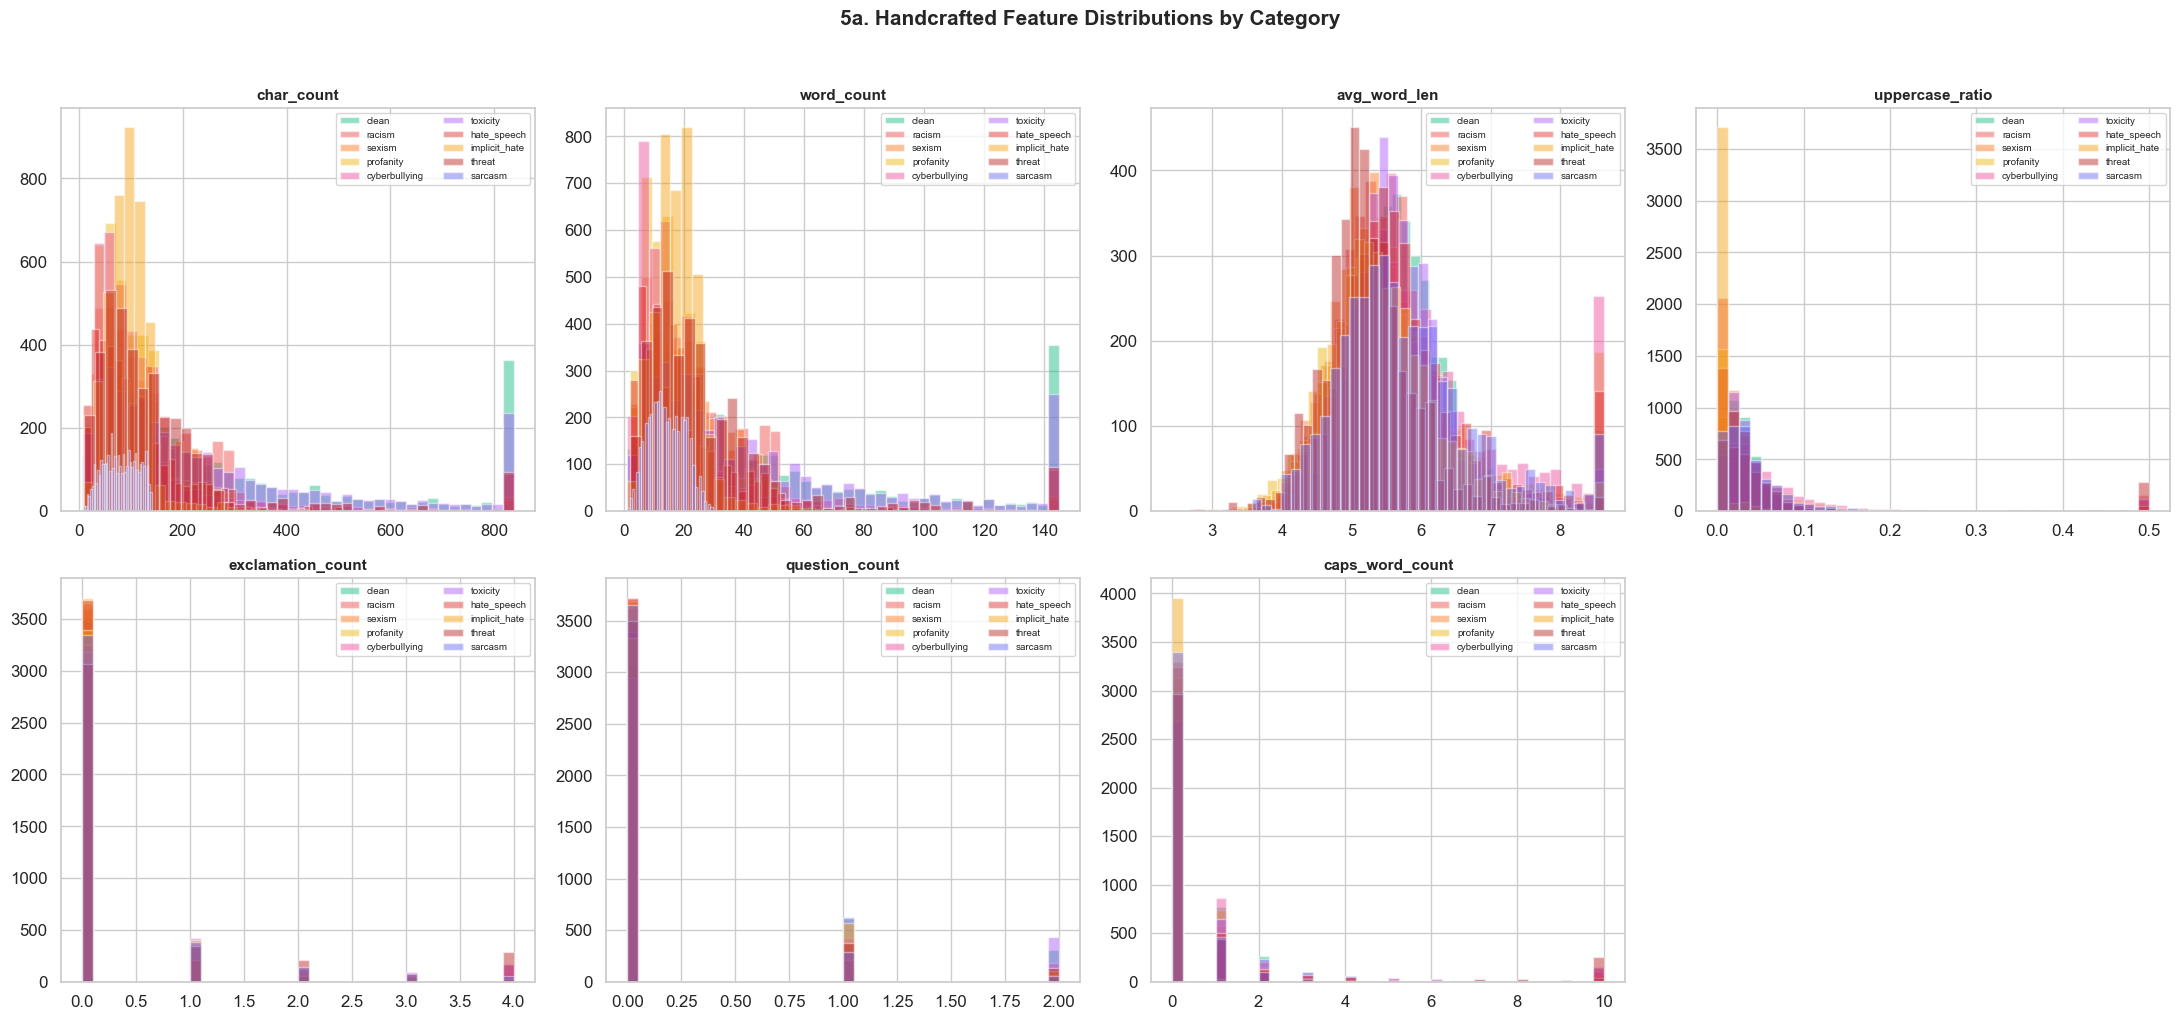

In [11]:
train_hc = pd.read_csv(DATA_DIR / "processed" / "train_handcrafted.csv")
train_hc["label"] = train_df["label"].values

feature_cols = train_hc.columns.drop("label")

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

labels_hc = [l for l in LABEL_NAMES if l in train_hc["label"].values]
for i, col in enumerate(feature_cols):
    ax = axes[i]
    for label in labels_hc:
        subset = train_hc[train_hc["label"] == label][col].clip(upper=train_hc[col].quantile(0.98))
        ax.hist(subset, bins=40, alpha=0.45, label=label, color=COLORS[label], edgecolor="white")
    ax.set_title(col, fontweight="bold", fontsize=11)
    ax.legend(fontsize=7, ncol=2)

# Hide unused subplot
if len(feature_cols) < len(axes):
    for j in range(len(feature_cols), len(axes)):
        axes[j].set_visible(False)

plt.suptitle("5a. Handcrafted Feature Distributions by Category", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

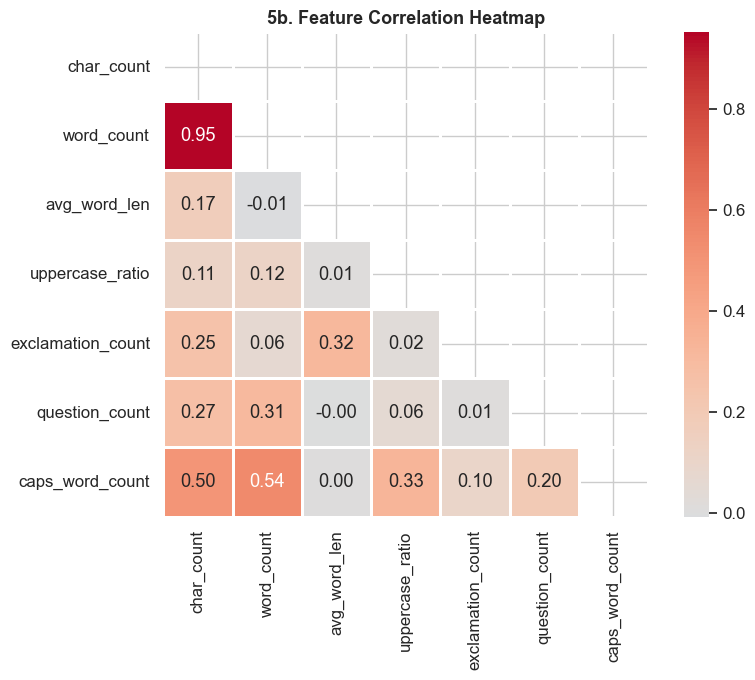

In [12]:
# 5b — Correlation heatmap of handcrafted features
fig, ax = plt.subplots(figsize=(9, 7))
corr = train_hc[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=ax, linewidths=1, linecolor="white", square=True)
ax.set_title("5b. Feature Correlation Heatmap", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

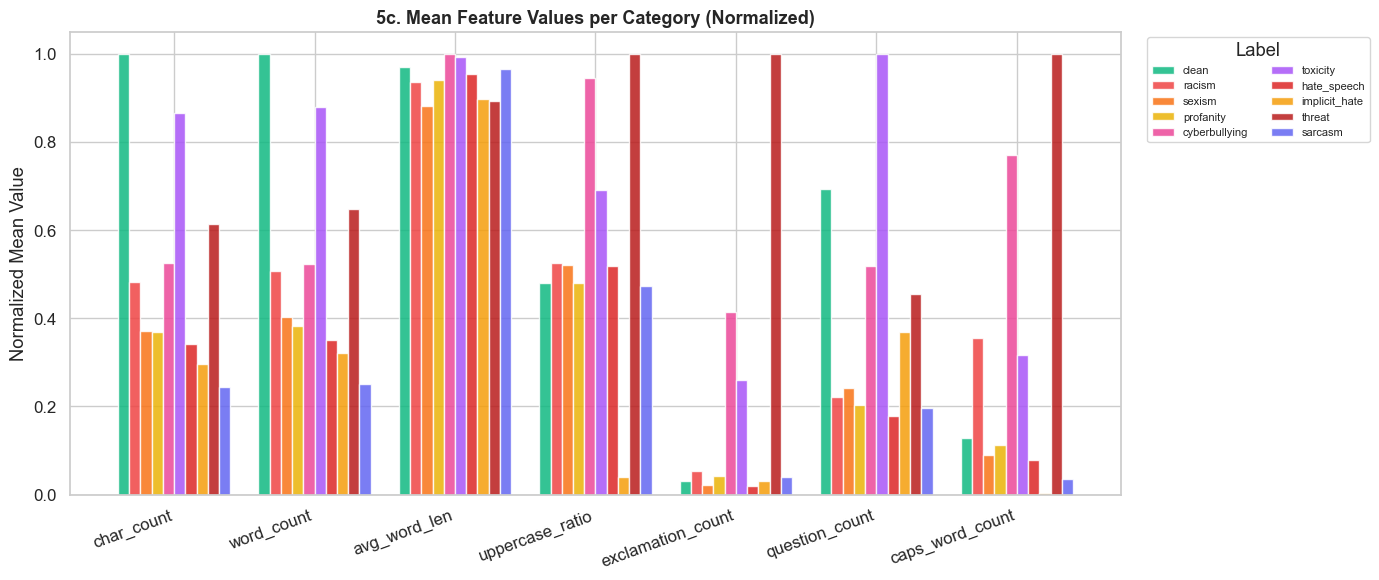

In [13]:
# 5c — Mean feature values per class (grouped bar chart)
mean_by_label = train_hc.groupby("label")[feature_cols].mean()
labels_hc = [l for l in LABEL_NAMES if l in mean_by_label.index]
n_l = len(labels_hc)
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(feature_cols))
width = 0.8 / n_l

for i, label in enumerate(labels_hc):
    vals = mean_by_label.loc[label].values
    vals_norm = vals / (mean_by_label.max().values + 1e-8)
    ax.bar(x + i * width, vals_norm, width, label=label, color=COLORS[label], edgecolor="white", alpha=0.85)

ax.set_xticks(x + (n_l - 1) * width / 2)
ax.set_xticklabels(feature_cols, rotation=20, ha="right")
ax.set_ylabel("Normalized Mean Value")
ax.set_title("5c. Mean Feature Values per Category (Normalized)", fontweight="bold", fontsize=13)
ax.legend(title="Label", fontsize=8, ncol=2, bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## 6. Data Source Comparison

Since we merged eight data sources (Davidson, Jigsaw v1/v2, Berkeley D-Lab, EDOS, HateXplain, ImplicitHate, TweetEval irony), we need to understand whether their text distributions are consistent. Mismatches could hurt model generalization.

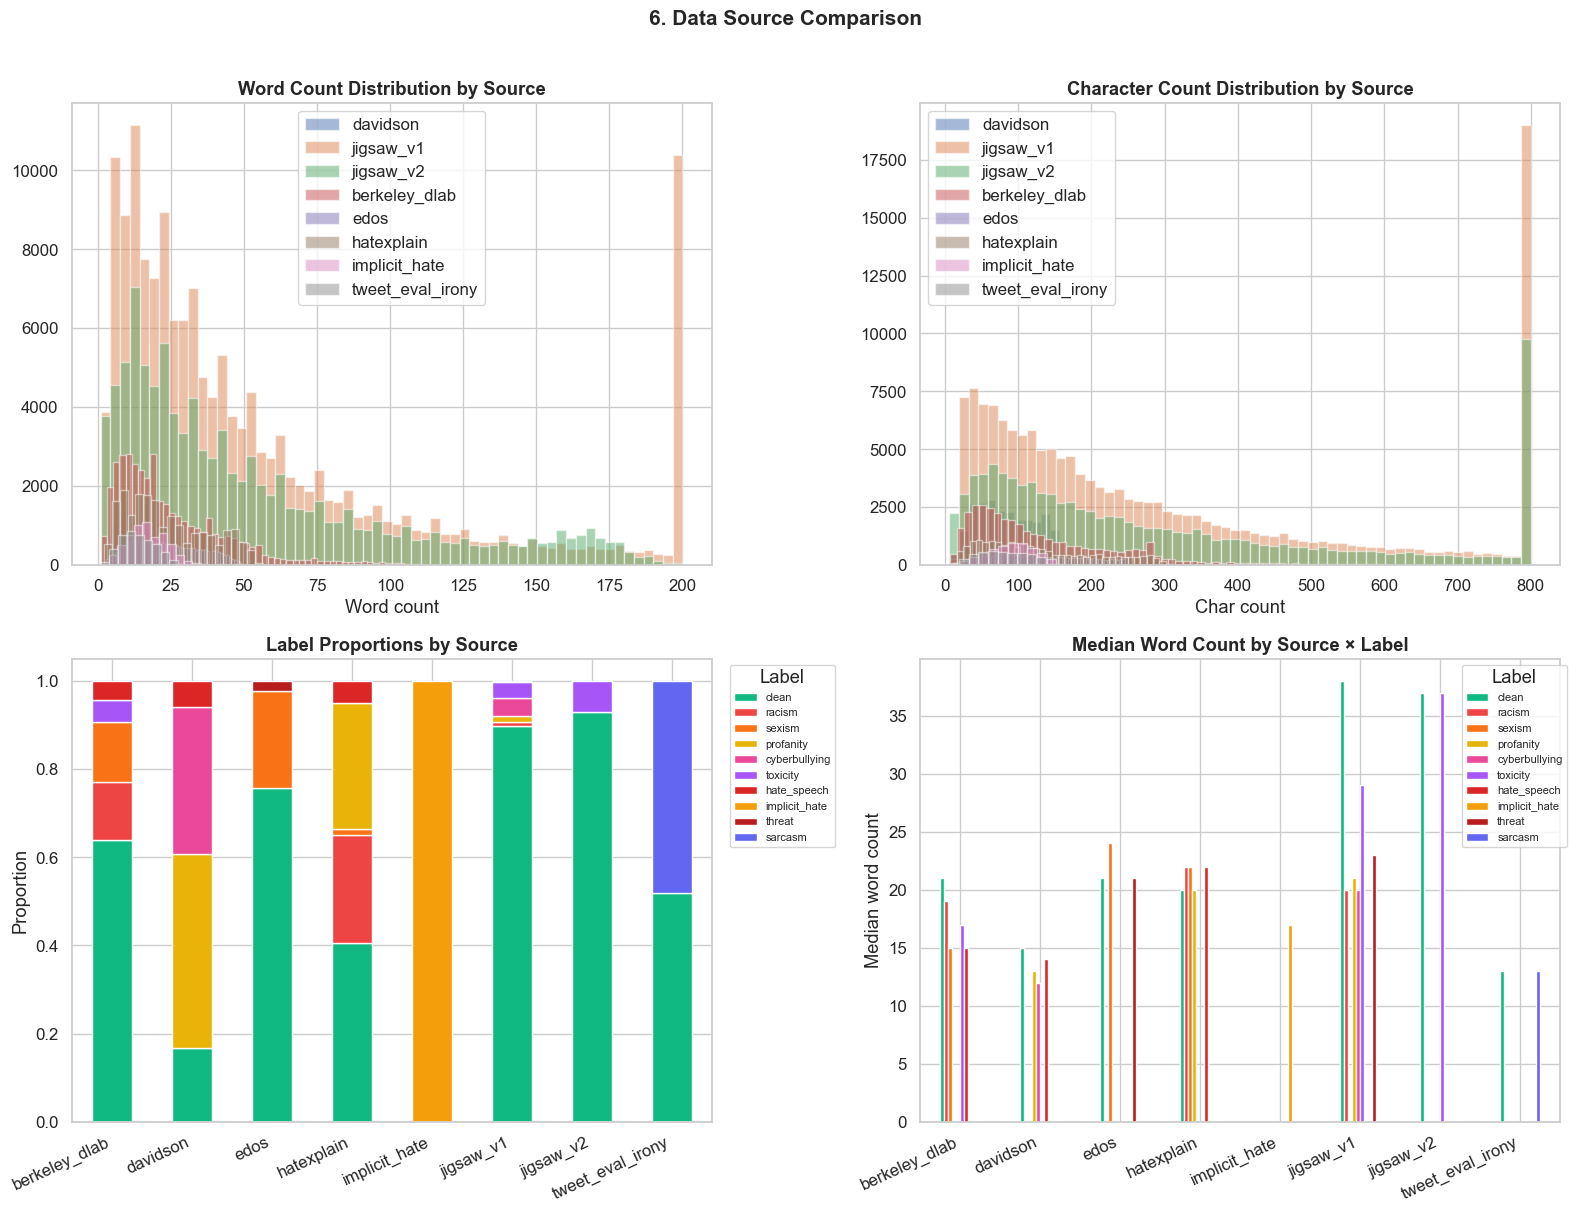


Samples per source:
source
jigsaw_v1           159571
jigsaw_v2            99669
berkeley_dlab        39565
davidson             24781
hatexplain           20148
edos                 19997
implicit_hate         6346
tweet_eval_irony      4598
Name: count, dtype: int64

Davidson avg words: 14.1
Jigsaw v1 avg words: 67.3
Jigsaw v2 avg words: 53.6


In [14]:
unified["char_count"] = unified["text"].str.len()
unified["word_count"] = unified["text"].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 6a — Word count distribution per source
for src in unified["source"].unique():
    subset = unified[unified["source"] == src]["word_count"].clip(upper=200)
    axes[0, 0].hist(subset, bins=60, alpha=0.5, label=src, edgecolor="white")
axes[0, 0].set_title("Word Count Distribution by Source", fontweight="bold")
axes[0, 0].set_xlabel("Word count")
axes[0, 0].legend()

# 6b — Char count distribution per source
for src in unified["source"].unique():
    subset = unified[unified["source"] == src]["char_count"].clip(upper=800)
    axes[0, 1].hist(subset, bins=60, alpha=0.5, label=src, edgecolor="white")
axes[0, 1].set_title("Character Count Distribution by Source", fontweight="bold")
axes[0, 1].set_xlabel("Char count")
axes[0, 1].legend()

# 6c — Label proportions per source (normalized stacked bar)
cross_norm = pd.crosstab(unified["source"], unified["label"], normalize="index")
cols6 = [c for c in LABEL_NAMES if c in cross_norm.columns]
cross_norm = cross_norm[cols6]
cross_norm.plot(kind="bar", stacked=True, color=[COLORS[c] for c in cols6], edgecolor="white", ax=axes[1, 0])
axes[1, 0].set_title("Label Proportions by Source", fontweight="bold")
axes[1, 0].set_ylabel("Proportion")
axes[1, 0].set_xlabel("")
axes[1, 0].legend(title="Label", fontsize=8, bbox_to_anchor=(1.02, 1), ncol=1)
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=25, ha="right")

# 6d — Median text length by source and label
median_lens = unified.groupby(["source", "label"])["word_count"].median().unstack()
median_lens = median_lens[[c for c in cols6 if c in median_lens.columns]]
median_lens.plot(kind="bar", color=[COLORS[c] for c in median_lens.columns], edgecolor="white", ax=axes[1, 1])
axes[1, 1].set_title("Median Word Count by Source × Label", fontweight="bold")
axes[1, 1].set_ylabel("Median word count")
axes[1, 1].set_xlabel("")
axes[1, 1].legend(title="Label", fontsize=8, bbox_to_anchor=(1.02, 1), ncol=1)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=25, ha="right")

plt.suptitle("6. Data Source Comparison", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\nSamples per source:")
print(unified["source"].value_counts())
print(f"\nDavidson avg words: {unified[unified['source']=='davidson']['word_count'].mean():.1f}")
print(f"Jigsaw v1 avg words: {unified[unified['source']=='jigsaw_v1']['word_count'].mean():.1f}")
print(f"Jigsaw v2 avg words: {unified[unified['source']=='jigsaw_v2']['word_count'].mean():.1f}")

## 7. Error Analysis Preview

We load the model evaluation results and visualize the confusion matrices and model comparison, providing context for the error analysis in the report.

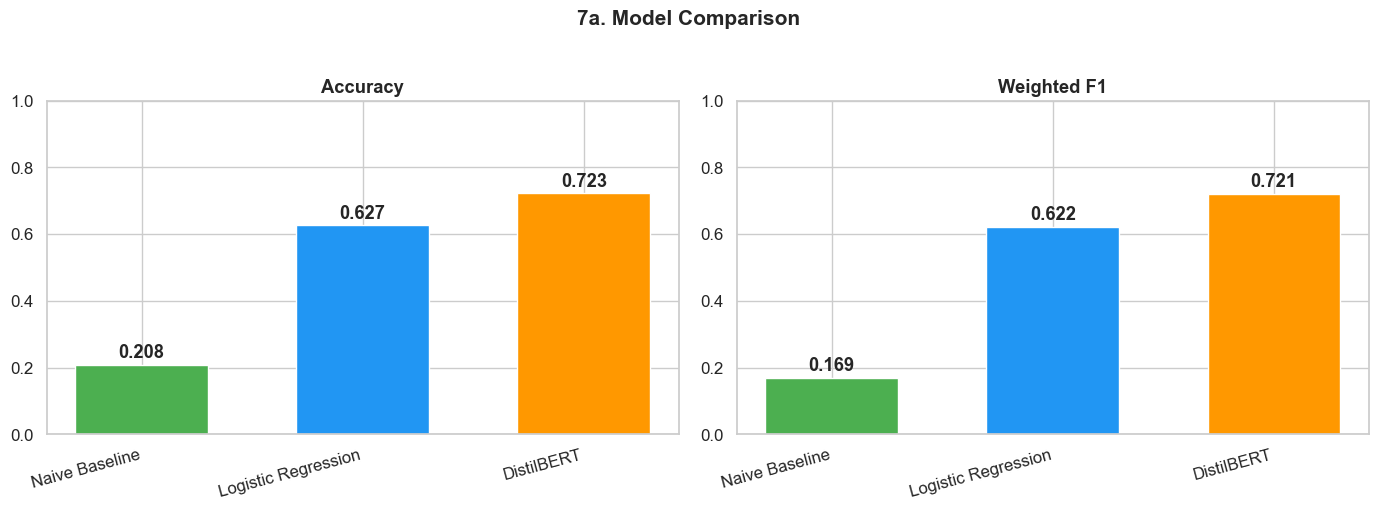

In [15]:
import json

OUTPUTS_DIR = DATA_DIR / "outputs"

with open(OUTPUTS_DIR / "full_results.json") as f:
    results = json.load(f)

comparison = pd.read_csv(OUTPUTS_DIR / "model_comparison.csv")

# 7a — Model comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = comparison["Model"]
x = np.arange(len(models))

bars1 = axes[0].bar(x, comparison["Accuracy"], color=["#4CAF50", "#2196F3", "#FF9800"], edgecolor="white", width=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15, ha="right")
axes[0].set_title("Accuracy", fontweight="bold")
axes[0].set_ylim(0, 1)
for bar, v in zip(bars1, comparison["Accuracy"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

bars2 = axes[1].bar(x, comparison["Weighted F1"], color=["#4CAF50", "#2196F3", "#FF9800"], edgecolor="white", width=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15, ha="right")
axes[1].set_title("Weighted F1", fontweight="bold")
axes[1].set_ylim(0, 1)
for bar, v in zip(bars2, comparison["Weighted F1"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

plt.suptitle("7a. Model Comparison", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

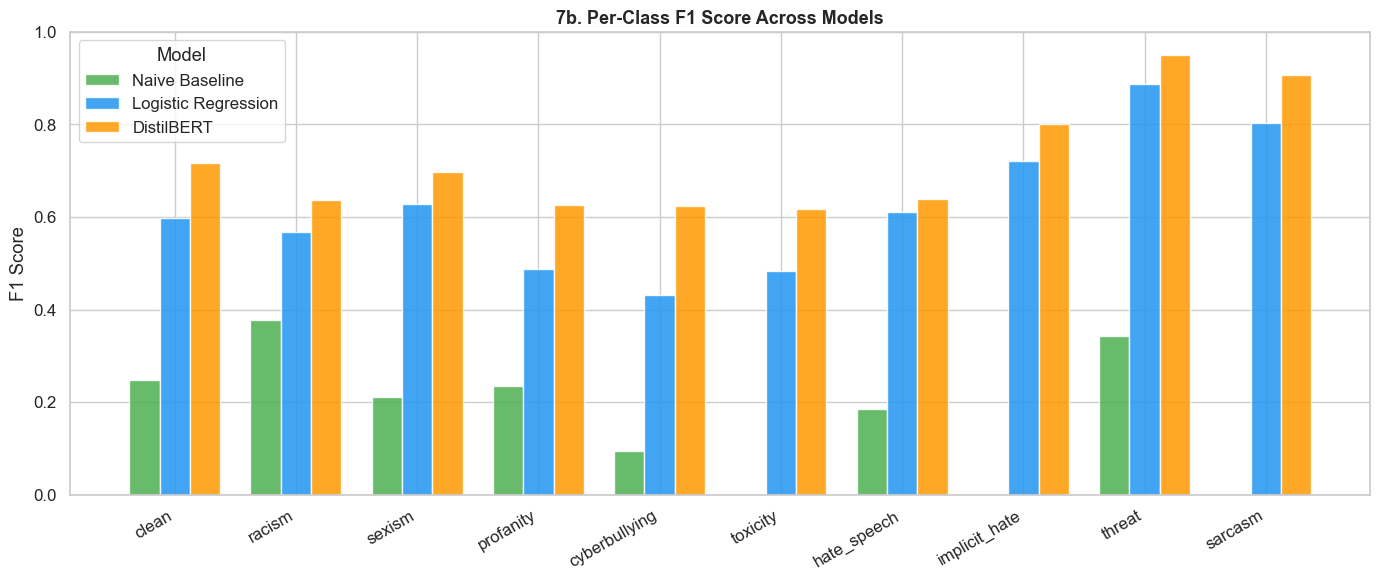

In [16]:
# 7b — Per-class F1 comparison across models (grouped bar)
report_labels = [l for l in LABEL_NAMES if l in results[0]["report"]]
n_labels = len(report_labels)
x = np.arange(n_labels)
width = 0.25
model_colors = ["#4CAF50", "#2196F3", "#FF9800"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, r in enumerate(results):
    f1s = [r["report"].get(l, {}).get("f1-score", 0) for l in report_labels]
    ax.bar(x + i * width, f1s, width, label=r["model"], color=model_colors[i], edgecolor="white", alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(report_labels, rotation=30, ha="right")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1)
ax.set_title("7b. Per-Class F1 Score Across Models", fontweight="bold", fontsize=13)
ax.legend(title="Model")
plt.tight_layout()
plt.show()

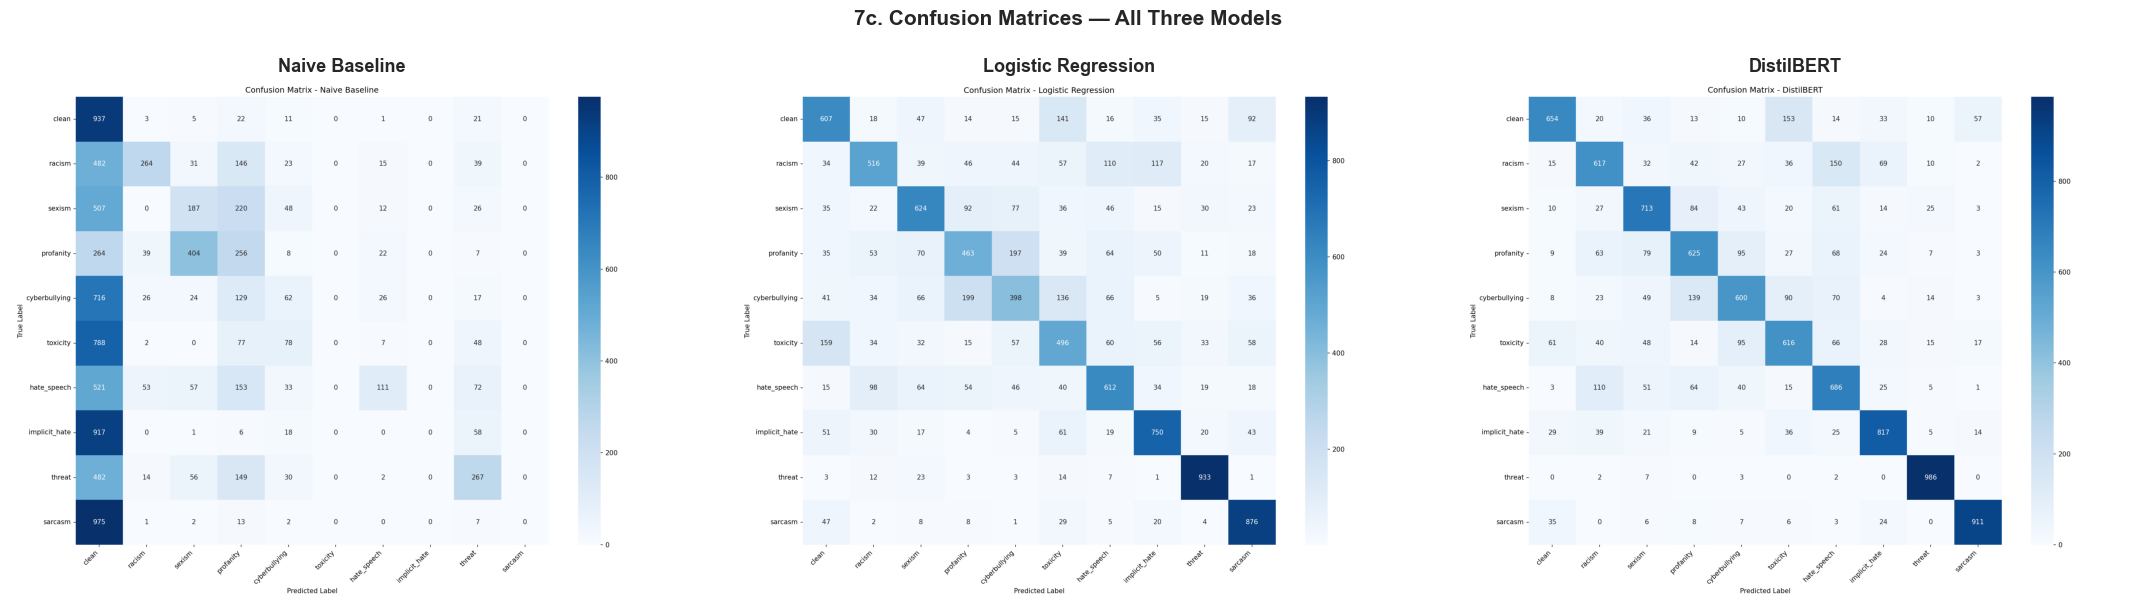

In [17]:
# 7c — Display saved confusion matrices side by side
from matplotlib.image import imread

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
cm_files = [
    ("confusion_matrix_naive_baseline.png", "Naive Baseline"),
    ("confusion_matrix_logistic_regression.png", "Logistic Regression"),
    ("confusion_matrix_distilbert.png", "DistilBERT"),
]
for i, (fname, title) in enumerate(cm_files):
    img = imread(OUTPUTS_DIR / fname)
    axes[i].imshow(img)
    axes[i].set_title(title, fontweight="bold", fontsize=13)
    axes[i].axis("off")

plt.suptitle("7c. Confusion Matrices — All Three Models", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

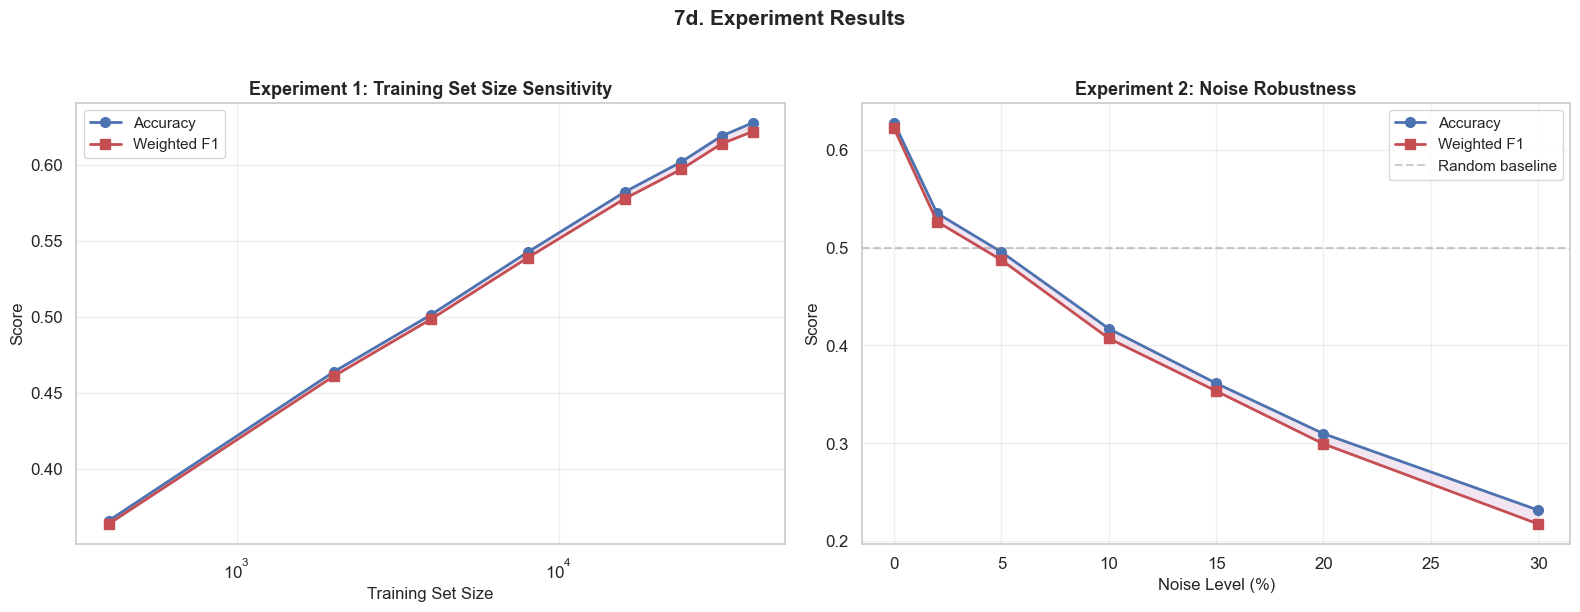

In [18]:
# 7d — Experiment results visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training size sensitivity
exp_size = pd.read_csv(OUTPUTS_DIR / "experiment_training_size.csv")
axes[0].plot(exp_size["n_samples"], exp_size["accuracy"], "b-o", label="Accuracy", linewidth=2, markersize=7)
axes[0].plot(exp_size["n_samples"], exp_size["weighted_f1"], "r-s", label="Weighted F1", linewidth=2, markersize=7)
axes[0].fill_between(exp_size["n_samples"], exp_size["accuracy"], exp_size["weighted_f1"], alpha=0.1, color="purple")
axes[0].set_xlabel("Training Set Size", fontsize=12)
axes[0].set_ylabel("Score", fontsize=12)
axes[0].set_title("Experiment 1: Training Set Size Sensitivity", fontweight="bold", fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale("log")

# Noise robustness
exp_noise = pd.read_csv(OUTPUTS_DIR / "experiment_noise_robustness.csv")
axes[1].plot(exp_noise["noise_level"] * 100, exp_noise["accuracy"], "b-o", label="Accuracy", linewidth=2, markersize=7)
axes[1].plot(exp_noise["noise_level"] * 100, exp_noise["weighted_f1"], "r-s", label="Weighted F1", linewidth=2, markersize=7)
axes[1].fill_between(exp_noise["noise_level"] * 100, exp_noise["accuracy"], exp_noise["weighted_f1"], alpha=0.1, color="purple")
axes[1].axhline(y=0.5, color="gray", linestyle="--", alpha=0.4, label="Random baseline")
axes[1].set_xlabel("Noise Level (%)", fontsize=12)
axes[1].set_ylabel("Score", fontsize=12)
axes[1].set_title("Experiment 2: Noise Robustness", fontweight="bold", fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle("7d. Experiment Results", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

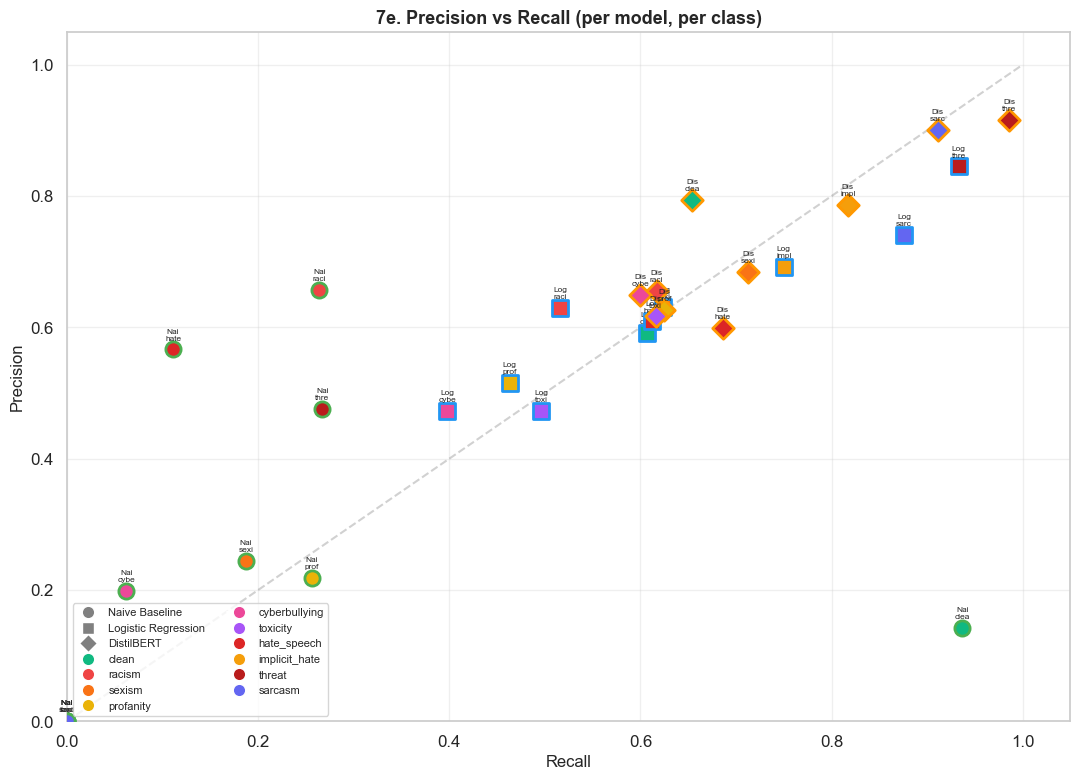

In [19]:
# 7e — Precision vs Recall scatter per model per class
fig, ax = plt.subplots(figsize=(11, 8))
markers = {"Naive Baseline": "o", "Logistic Regression": "s", "DistilBERT": "D"}
model_colors_map = {"Naive Baseline": "#4CAF50", "Logistic Regression": "#2196F3", "DistilBERT": "#FF9800"}
report_labels = [l for l in LABEL_NAMES if l in results[0]["report"]]

for r in results:
    for label in report_labels:
        entry = r["report"].get(label, {})
        prec, rec = entry.get("precision", 0), entry.get("recall", 0)
        ax.scatter(rec, prec, s=120, marker=markers.get(r["model"], "o"),
                   color=COLORS.get(label, "#888"), edgecolors=model_colors_map.get(r["model"], "gray"), linewidths=2,
                   zorder=3)
        ax.annotate(f'{r["model"][:3]}\n{label[:4]}', (rec, prec),
                    fontsize=6, ha="center", va="bottom", textcoords="offset points", xytext=(0, 6))

ax.plot([0, 1], [0, 1], "k--", alpha=0.2)
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("7e. Precision vs Recall (per model, per class)", fontweight="bold", fontsize=13)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=9, label="Naive Baseline"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray", markersize=9, label="Logistic Regression"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor="gray", markersize=9, label="DistilBERT"),
] + [Line2D([0], [0], marker="o", color="w", markerfacecolor=COLORS[l], markersize=9, label=l) for l in report_labels]
ax.legend(handles=legend_elements, loc="lower left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Key Takeaways

1. **Class imbalance** — Raw data is dominated by clean; harmful categories (threat, sarcasm, hate_speech, etc.) are minority. Balanced sampling (5k per class) is critical.
2. **Text length** — Tweets (Davidson, EDOS) are short; Jigsaw/Berkeley comments are longer. DistilBERT's 128-token limit covers most texts.
3. **10-class taxonomy** — clean, racism, sexism, profanity, cyberbullying, toxicity, hate_speech, implicit_hate, threat, sarcasm. Overlap between similar categories explains some confusion.
4. **TF-IDF** — Each class has distinctive vocabulary; overlap in top TF-IDF features between similar classes explains confusion.
5. **Handcrafted features** — `uppercase_ratio` and `caps_word_count` help separate categories.
6. **Data source differences** — Eight sources add diversity but introduce distribution variance.
7. **Model progression** — Naive (F1≈0.17) → LR (F1≈0.62) → DistilBERT (F1≈0.72). DistilBERT excels on threat and sarcasm; confusion remains between toxicity/cyberbullying/profanity and between hate_speech/implicit_hate.